# L1 R-GAT GraphMask：保留重要消息的职业—关系—职业主图

本 notebook 复用已下载的 `occupation_pair_report`，不重新训练 R-GAT 或 GraphMask。它沿用旧 attention 图的布局：**行是来源职业 $O_s$、列是目标职业 $O_t$、每个面板是一种精确有向关系 $R$**。

主图的每个格子填写的是 GraphMask 的 **hard-retained direct-message share**：

$$100\times\frac{K_{l,O_s,R,O_t}}{\sum_{O_s',R'}K_{l,O_s',R',O_t}}\%. $$

其中 $K$ 是 hard gate 为 1 的、直接进入测试节点的消息观测数；分母是同一 Layer、同一目标职业的全部 hard-retained 直接消息。因此它表示：在模型为预测该目标职业而保留的消息预算中，该 $(O_s,R,O_t)$ 组合所占的份额。主图以百分比显示该份额（例如 5.1%）；笔记本末尾审计表保留精确的 $K$、$N$、留存率和节点覆盖度。

这不是 attention 的平均权重，也不是单独的留存率 $K/N$。留存率可在扩展部分作为补充检验，但主图优先回答“重要消息预算主要来自哪里”。

## 使用范围与可配置项

默认配置画出 Layer 0 的五种亲属关系（`child`、`spouse`、`sibling`、`father`、`mother`），以全部带真值的测试节点为目标节点。`__rev` 关系保持独立；如需分析反向关系，只需在 `EXACT_RELATIONS` 中显式加入。

`COHORT = 'correct_only'` 可生成原模型预测正确测试节点的敏感性图。`SOURCE_VISIBILITY` 只用于分层检查：对 `hidden_validation_or_test`，来源职业是事后真值分层，不能解释为模型直接读取该职业输入。

In [1]:
from __future__ import annotations

import os
from math import ceil
from pathlib import Path

# Keep Matplotlib's cache outside the repository, including when the notebook runs on a server.
MPL_CACHE = Path('/tmp/rgcn_matplotlib')
MPL_CACHE.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPL_CACHE))

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option('display.max_columns', 50)


def find_project_root(start: Path) -> Path:
    """Find the repository whether Jupyter starts in its root or in notebooks/."""
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'runs_graphmask').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('Could not locate the project root containing runs_graphmask/.')


PROJECT_ROOT = find_project_root(Path.cwd())
VISUALIZATION_DIR = PROJECT_ROOT / 'visualization'
VISUALIZATION_DIR.mkdir(parents=True, exist_ok=True)
print(f'Project root: {PROJECT_ROOT}')


Project root: /Users/wangyue/RGCN


In [2]:
# Report downloaded from the server; the notebook binds to this one checkpoint/probe pair.
REPORT_DIR = PROJECT_ROOT / 'runs_graphmask' / 'level1_rgat' / 'seed_42' / 'occupation_pair_report'

# 'all_test' is the primary analysis; 'correct_only' is the original-model-correct sensitivity analysis.
COHORT = 'all_test'

# GraphMask layers are reported separately.  Default: Layer 0; set GRAPHMASK_LAYER=1 for Layer 1.
LAYER = int(os.environ.get('GRAPHMASK_LAYER', '0'))
if LAYER not in (0, 1):
    raise ValueError('GRAPHMASK_LAYER must be 0 or 1.')

# Exact directed relations: no __rev merging.  Add, for example, 'father__rev' to show it separately.
FORWARD_KINSHIP = ('child', 'spouse', 'sibling', 'father', 'mother')
EXACT_RELATIONS = list(FORWARD_KINSHIP)
KINSHIP_DIRECTED_RELATIONS = frozenset((*FORWARD_KINSHIP, *(f'{relation}__rev' for relation in FORWARD_KINSHIP)))
RELATION_FAMILIES = ('kinship', 'nonkinship')

# A displayed cell must be supported by at least this many candidate target nodes.
# Override from the terminal, e.g. GRAPHMASK_MIN_NODE_SUPPORT=1, without editing the notebook.
MIN_NODE_SUPPORT = int(os.environ.get('GRAPHMASK_MIN_NODE_SUPPORT', '100'))
if MIN_NODE_SUPPORT < 1:
    raise ValueError('GRAPHMASK_MIN_NODE_SUPPORT must be at least 1.')

# Set to None for the principal all-known-sources view.  Alternatives are
# 'visible_train' and 'hidden_validation_or_test'.  This uses the visibility table.
SOURCE_VISIBILITY = None

# Static figure output.  GRAPHMASK_OUTPUT_TAG avoids overwriting the default figure.
OUTPUT_TAG = os.environ.get('GRAPHMASK_OUTPUT_TAG', '').strip()
output_tag_suffix = f'_{OUTPUT_TAG}' if OUTPUT_TAG else ''
OUTPUT_FILENAME = (
    f'graphmask_l1_rgat_{COHORT}_layer{LAYER}_retained_share_exact_kinship{output_tag_suffix}.png'
)
FAMILY_OUTPUT_FILENAME = (
    f'graphmask_l1_rgat_{COHORT}_layer{LAYER}_retained_share_relation_family{output_tag_suffix}.png'
)

assert REPORT_DIR.exists(), f'Missing downloaded report directory: {REPORT_DIR}'
print(f'Report: {REPORT_DIR}')


Report: /Users/wangyue/RGCN/runs_graphmask/level1_rgat/seed_42/occupation_pair_report


In [3]:
def load_pair_report(report_dir: Path, cohort: str, source_visibility: str | None) -> pd.DataFrame:
    if source_visibility is not None:
        path = report_dir / 'occupation_pairs_by_visibility.csv'
    elif cohort == 'all_test':
        path = report_dir / 'occupation_pairs_all_test.csv'
    elif cohort == 'correct_only':
        path = report_dir / 'occupation_pairs_correct_only.csv'
    else:
        raise ValueError("COHORT must be 'all_test' or 'correct_only'.")

    frame = pd.read_csv(path)
    if 'cohort' in frame.columns:
        frame = frame.loc[frame['cohort'].eq(cohort)].copy()
    if source_visibility is not None:
        if 'source_visibility' not in frame.columns:
            raise ValueError('The visibility report lacks source_visibility.')
        frame = frame.loc[frame['source_visibility'].eq(source_visibility)].copy()
    if frame.empty:
        raise ValueError(f'No rows remain for cohort={cohort!r}, source_visibility={source_visibility!r}.')
    print(f'Loaded {len(frame):,} aggregation rows from {path.name}')
    return frame


report_df = load_pair_report(REPORT_DIR, COHORT, SOURCE_VISIBILITY)

# Early report versions named the exact directed-relation column relation; later versions may call it relation_directed.
RELATION_COLUMN = 'relation_directed' if 'relation_directed' in report_df.columns else 'relation'
REQUIRED_COLUMNS = {
    'layer', 'source_l1_id', 'source_l1', 'target_l1_id', 'target_l1', RELATION_COLUMN,
    'candidate_message_n', 'hard_retained_message_n', 'candidate_node_count',
    'hard_retention_rate', 'retained_share_of_Ot_budget',
}
missing = REQUIRED_COLUMNS.difference(report_df.columns)
if missing:
    raise ValueError(f'Pair report is missing required fields: {sorted(missing)}')

report_df = report_df.rename(columns={RELATION_COLUMN: 'directed_relation'}).copy()
report_df['directed_relation'] = report_df['directed_relation'].astype(str)

# Use ids rather than alphabetical names so the source/target class order is stable.
layer_df = report_df.loc[report_df['layer'].eq(LAYER)].copy()
if layer_df.empty:
    raise ValueError(f'No rows found for Layer {LAYER}.')

source_order = (
    layer_df[['source_l1_id', 'source_l1']]
    .drop_duplicates()
    .sort_values('source_l1_id')
    .set_index('source_l1_id')['source_l1']
)
target_order = (
    layer_df[['target_l1_id', 'target_l1']]
    .drop_duplicates()
    .sort_values('target_l1_id')
    .set_index('target_l1_id')['target_l1']
)
source_names = source_order.tolist()
target_names = target_order.tolist()

available_relations = set(layer_df['directed_relation'])
relations_to_plot = [relation for relation in EXACT_RELATIONS if relation in available_relations]
unavailable_relations = [relation for relation in EXACT_RELATIONS if relation not in available_relations]
if unavailable_relations:
    print(f'Not present in this report and skipped: {unavailable_relations}')
if not relations_to_plot:
    raise ValueError('None of EXACT_RELATIONS occur in the selected report/layer.')

# The formal ranking threshold is candidate_node_count >= 100; apply the same transparent rule to the figure.
plot_df = layer_df.loc[
    layer_df['directed_relation'].isin(relations_to_plot)
    & layer_df['candidate_node_count'].ge(MIN_NODE_SUPPORT)
].copy()

print(f'Layer {LAYER}; plotted relations: {relations_to_plot}')
print(f'Cells meeting candidate-node support ≥ {MIN_NODE_SUPPORT}: {len(plot_df):,}')


Loaded 1,772 aggregation rows from occupation_pairs_all_test.csv
Layer 0; plotted relations: ['child', 'spouse', 'sibling', 'father', 'mother']
Cells meeting candidate-node support ≥ 100: 65


In [4]:
# Validation: before any display/support filtering, each (Layer, target L1) retained-share budget sums to one.
budget_check = (
    report_df.groupby(['layer', 'target_l1_id', 'target_l1'], as_index=False)['retained_share_of_Ot_budget']
    .sum()
    .rename(columns={'retained_share_of_Ot_budget': 'retained_share_sum'})
)
budget_check['absolute_error_from_one'] = (budget_check['retained_share_sum'] - 1.0).abs()
display(budget_check)
assert budget_check['absolute_error_from_one'].max() < 1e-8, (
    'The retained-share denominator does not reconcile to one; do not interpret the heatmap.'
)


,layer,target_l1_id,target_l1,retained_share_sum,absolute_error_from_one
0,0,0,Culture,1.0,7.993606e-15
1,0,1,Discovery/Science,1.0,6.883383e-15
2,0,2,Leadership,1.0,6.217249e-15
3,0,3,Other,1.0,7.438494e-15
4,0,4,Sports/Games,1.0,3.108624e-15
5,1,0,Culture,1.0,6.883383e-15
6,1,1,Discovery/Science,1.0,5.884182e-15
7,1,2,Leadership,1.0,6.439294e-15
8,1,3,Other,1.0,1.165734e-14
9,1,4,Sports/Games,1.0,5.218048e-15


In [5]:
def _empty_share_matrix() -> pd.DataFrame:
    return pd.DataFrame(np.nan, index=source_names, columns=target_names, dtype=float)


def _source_target_share_matrix(panel: pd.DataFrame, *, label: str) -> pd.DataFrame:
    """Place one complete source-by-target report panel in the stable L1 order."""
    key_columns = ['source_l1_id', 'target_l1_id']
    if panel.duplicated(key_columns).any():
        raise ValueError(f'Duplicate (source, target) cells for {label}.')

    values = _empty_share_matrix()
    source_lookup = {class_id: name for class_id, name in source_order.items()}
    target_lookup = {class_id: name for class_id, name in target_order.items()}
    for row in panel.itertuples(index=False):
        values.loc[source_lookup[row.source_l1_id], target_lookup[row.target_l1_id]] = (
            row.retained_share_of_Ot_budget
        )
    return values


def relation_matrix(relation: str) -> pd.DataFrame:
    """Return one exact-directed-relation source-by-target share matrix."""
    panel = plot_df.loc[plot_df['directed_relation'].eq(relation)].copy()
    return _source_target_share_matrix(panel, label=f'relation {relation!r}')


def relation_family(relation: str) -> str:
    """Use the exact same five-forward-relation family map as the attention notebook."""
    return 'kinship' if relation in KINSHIP_DIRECTED_RELATIONS else 'nonkinship'


def relation_family_matrix() -> pd.DataFrame:
    """Aggregate exact directed relations into kinship/nonkinship without losing budget mass."""
    family_df = layer_df.copy()
    family_df['relation_family'] = family_df['directed_relation'].map(relation_family)
    family_df = (
        family_df.groupby(
            ['source_l1_id', 'source_l1', 'target_l1_id', 'target_l1', 'relation_family'],
            as_index=False,
        )
        .agg(retained_share_of_Ot_budget=('retained_share_of_Ot_budget', 'sum'))
    )

    # Do not apply the per-relation support filter here: candidate-node counts are not additive
    # across relations, while retained-message budget shares are.  This panel therefore retains
    # the complete direct-message budget before the two relation families are summed.
    if SOURCE_VISIBILITY is None:
        family_budget_check = (
            family_df.groupby(['target_l1_id', 'target_l1'], as_index=False)['retained_share_of_Ot_budget']
            .sum()
        )
        family_budget_error = (family_budget_check['retained_share_of_Ot_budget'] - 1.0).abs().max()
        assert family_budget_error < 1e-8, (
            'Relation-family shares do not reconstruct each target occupation budget.'
        )

    family_matrices = {
        family: _source_target_share_matrix(
            family_df.loc[family_df['relation_family'].eq(family)].copy(),
            label=f'relation family {family!r}',
        )
        for family in RELATION_FAMILIES
    }
    return pd.concat(family_matrices, names=['relation_family', 'source_l1'])


def _configure_share_colourbar(colourbar) -> None:
    colourbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    colourbar.set_label('Hard-retained direct-message share (%)', fontsize=12.5, labelpad=12)
    colourbar.ax.tick_params(labelsize=10.5)


def plot_retained_share_stacked(relations: list[str], output_path: Path) -> None:
    """Draw one relation-stacked matrix, matching the previous kinship-heatmap structure."""
    matrices = [(relation, relation_matrix(relation)) for relation in relations]
    stacked_values = np.vstack([matrix.to_numpy() for _, matrix in matrices])
    finite_values = stacked_values[np.isfinite(stacked_values)]
    if finite_values.size == 0:
        raise ValueError('No cells satisfy the configured support threshold.')

    n_source = len(source_names)
    n_target = len(target_names)
    n_rows = len(relations) * n_source
    vmax = float(finite_values.max())
    cmap = plt.colormaps['Blues'].copy()
    cmap.set_bad('#f4f4f4')

    figure = plt.figure(figsize=(10.8, 20.5))
    label_axis = figure.add_axes([0.075, 0.115, 0.245, 0.745])
    heat_axis = figure.add_axes([0.320, 0.115, 0.545, 0.745])
    colourbar_axis = figure.add_axes([0.905, 0.270, 0.030, 0.420])

    image = heat_axis.imshow(
        stacked_values, cmap=cmap, vmin=0.0, vmax=vmax, aspect='auto', interpolation='none'
    )
    heat_axis.set_xlim(-0.5, n_target - 0.5)
    heat_axis.set_ylim(n_rows - 0.5, -0.5)
    heat_axis.set_yticks([])
    heat_axis.set_xticks(range(n_target))
    heat_axis.set_xticklabels([name.replace('/', '/\n') for name in target_names], fontsize=13)
    heat_axis.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False, pad=10)

    heat_axis.set_xticks(np.arange(-0.5, n_target, 1), minor=True)
    heat_axis.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    heat_axis.grid(which='minor', color='white', linewidth=1.0)
    heat_axis.tick_params(which='minor', bottom=False, left=False)
    for spine in heat_axis.spines.values():
        spine.set_linewidth(1.1)

    label_axis.set_xlim(0.0, 1.0)
    label_axis.set_ylim(n_rows - 0.5, -0.5)
    label_axis.set_xticks([])
    label_axis.set_yticks([])
    for spine in label_axis.spines.values():
        spine.set_linewidth(1.1)

    for relation_index, (relation, matrix) in enumerate(matrices):
        start = relation_index * n_source
        group_center = start + (n_source - 1) / 2
        label_axis.text(0.12, group_center, relation, ha='center', va='center', fontsize=15)
        for source_index, source_name in enumerate(source_names):
            label_axis.text(0.93, start + source_index, source_name, ha='right', va='center', fontsize=13)
            for target_index in range(n_target):
                value = matrix.iat[source_index, target_index]
                if not np.isfinite(value):
                    continue
                text_colour = 'white' if value / vmax >= 0.58 else '#202020'
                heat_axis.text(
                    target_index, start + source_index, f'{value:.1%}',
                    ha='center', va='center', color=text_colour, fontsize=12.5,
                )

    for boundary in range(n_source, n_rows, n_source):
        y = boundary - 0.5
        heat_axis.axhline(y, color='#505050', linewidth=1.65)
        label_axis.axhline(y, color='#505050', linewidth=1.65)

    _configure_share_colourbar(figure.colorbar(image, cax=colourbar_axis))

    figure.suptitle(
        f'R-GAT GraphMask: retained message budget share for exact kinship relations — Layer {LAYER}',
        fontsize=20, y=0.970,
    )
    figure.text(0.595, 0.060, 'Target test-node L1 occupation $O_t$', ha='center', fontsize=15)
    cohort_label = 'all labelled test nodes' if COHORT == 'all_test' else 'original-model-correct test nodes'
    visibility_label = '' if SOURCE_VISIBILITY is None else f'; source visibility = {SOURCE_VISIBILITY}'
    blank_note = (
        'Blank = no observed direct message.'
        if MIN_NODE_SUPPORT == 1
        else f'Blank = < {MIN_NODE_SUPPORT} candidate target nodes or no observed direct message.'
    )
    figure.text(
        0.5, 0.020,
        f'Cell percentage = 100 × K / Σ$_{{O_s,R}}$K for the same Layer and target occupation; {cohort_label}{visibility_label}. '
        f'{blank_note} Each target-occupation budget includes all exact directed relations, not only these kinship relations.',
        ha='center', va='bottom', fontsize=9.5, wrap=True,
    )
    figure.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(figure)


def plot_relation_family_share(output_path: Path) -> None:
    """Draw the old relation-family layout using retained-message budget shares."""
    family_values = relation_family_matrix()
    ordered_rows = [(source, family) for source in source_names for family in RELATION_FAMILIES]
    stacked_values = np.vstack([family_values.loc[(family, source)].to_numpy() for source, family in ordered_rows])
    finite_values = stacked_values[np.isfinite(stacked_values)]
    if finite_values.size == 0:
        raise ValueError('No observed relation-family messages remain for this layer.')

    n_source = len(source_names)
    n_target = len(target_names)
    n_rows = n_source * len(RELATION_FAMILIES)
    vmax = float(finite_values.max())
    cmap = plt.colormaps['Blues'].copy()
    cmap.set_bad('#f4f4f4')

    figure = plt.figure(figsize=(10.8, 11.8))
    label_axis = figure.add_axes([0.060, 0.125, 0.310, 0.700])
    heat_axis = figure.add_axes([0.370, 0.125, 0.495, 0.700])
    colourbar_axis = figure.add_axes([0.905, 0.285, 0.030, 0.370])

    image = heat_axis.imshow(
        stacked_values, cmap=cmap, vmin=0.0, vmax=vmax, aspect='auto', interpolation='none'
    )
    heat_axis.set_xlim(-0.5, n_target - 0.5)
    heat_axis.set_ylim(n_rows - 0.5, -0.5)
    heat_axis.set_yticks([])
    heat_axis.set_xticks(range(n_target))
    heat_axis.set_xticklabels([name.replace('/', '/\n') for name in target_names], fontsize=13)
    heat_axis.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False, pad=10)
    heat_axis.set_xticks(np.arange(-0.5, n_target, 1), minor=True)
    heat_axis.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    heat_axis.grid(which='minor', color='white', linewidth=1.0)
    heat_axis.tick_params(which='minor', bottom=False, left=False)
    for spine in heat_axis.spines.values():
        spine.set_linewidth(1.1)

    label_axis.set_xlim(0.0, 1.0)
    label_axis.set_ylim(n_rows - 0.5, -0.5)
    label_axis.set_xticks([])
    label_axis.set_yticks([])
    for spine in label_axis.spines.values():
        spine.set_linewidth(1.1)

    for source_index, source_name in enumerate(source_names):
        start = source_index * len(RELATION_FAMILIES)
        label_axis.text(0.52, start + 0.5, source_name.replace('/', '/\n'), ha='center', va='center', fontsize=14)
        for family_index, family in enumerate(RELATION_FAMILIES):
            row = start + family_index
            label_axis.text(0.96, row, family, ha='right', va='center', fontsize=13)
            for target_index, value in enumerate(stacked_values[row]):
                if not np.isfinite(value):
                    continue
                text_colour = 'white' if value / vmax >= 0.58 else '#202020'
                heat_axis.text(
                    target_index, row, f'{value:.1%}',
                    ha='center', va='center', color=text_colour, fontsize=12.5,
                )

    for boundary in range(len(RELATION_FAMILIES), n_rows, len(RELATION_FAMILIES)):
        y = boundary - 0.5
        heat_axis.axhline(y, color='#505050', linewidth=1.65)
        label_axis.axhline(y, color='#505050', linewidth=1.65)

    label_axis.text(0.09, (n_rows - 1) / 2, 'Source L1 occupation $O_s$', rotation=90, ha='center', va='center', fontsize=14)
    _configure_share_colourbar(figure.colorbar(image, cax=colourbar_axis))

    figure.suptitle(
        f'R-GAT GraphMask: retained message budget share by relation family — Layer {LAYER}',
        fontsize=20, y=0.970,
    )
    figure.text(0.615, 0.062, 'Target test-node L1 occupation $O_t$', ha='center', fontsize=15)
    cohort_label = 'all labelled test nodes' if COHORT == 'all_test' else 'original-model-correct test nodes'
    visibility_label = '' if SOURCE_VISIBILITY is None else f'; source visibility = {SOURCE_VISIBILITY}'
    figure.text(
        0.5, 0.020,
        f'Cell percentage = 100 × K$_{{family}}$ / Σ$_{{O_s,R}}$K for the same Layer and target occupation; {cohort_label}{visibility_label}. '
        'Kinship = child, spouse, sibling, father and mother, plus their __rev forms; nonkinship = every other exact directed relation.',
        ha='center', va='bottom', fontsize=9.5, wrap=True,
    )
    figure.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(figure)


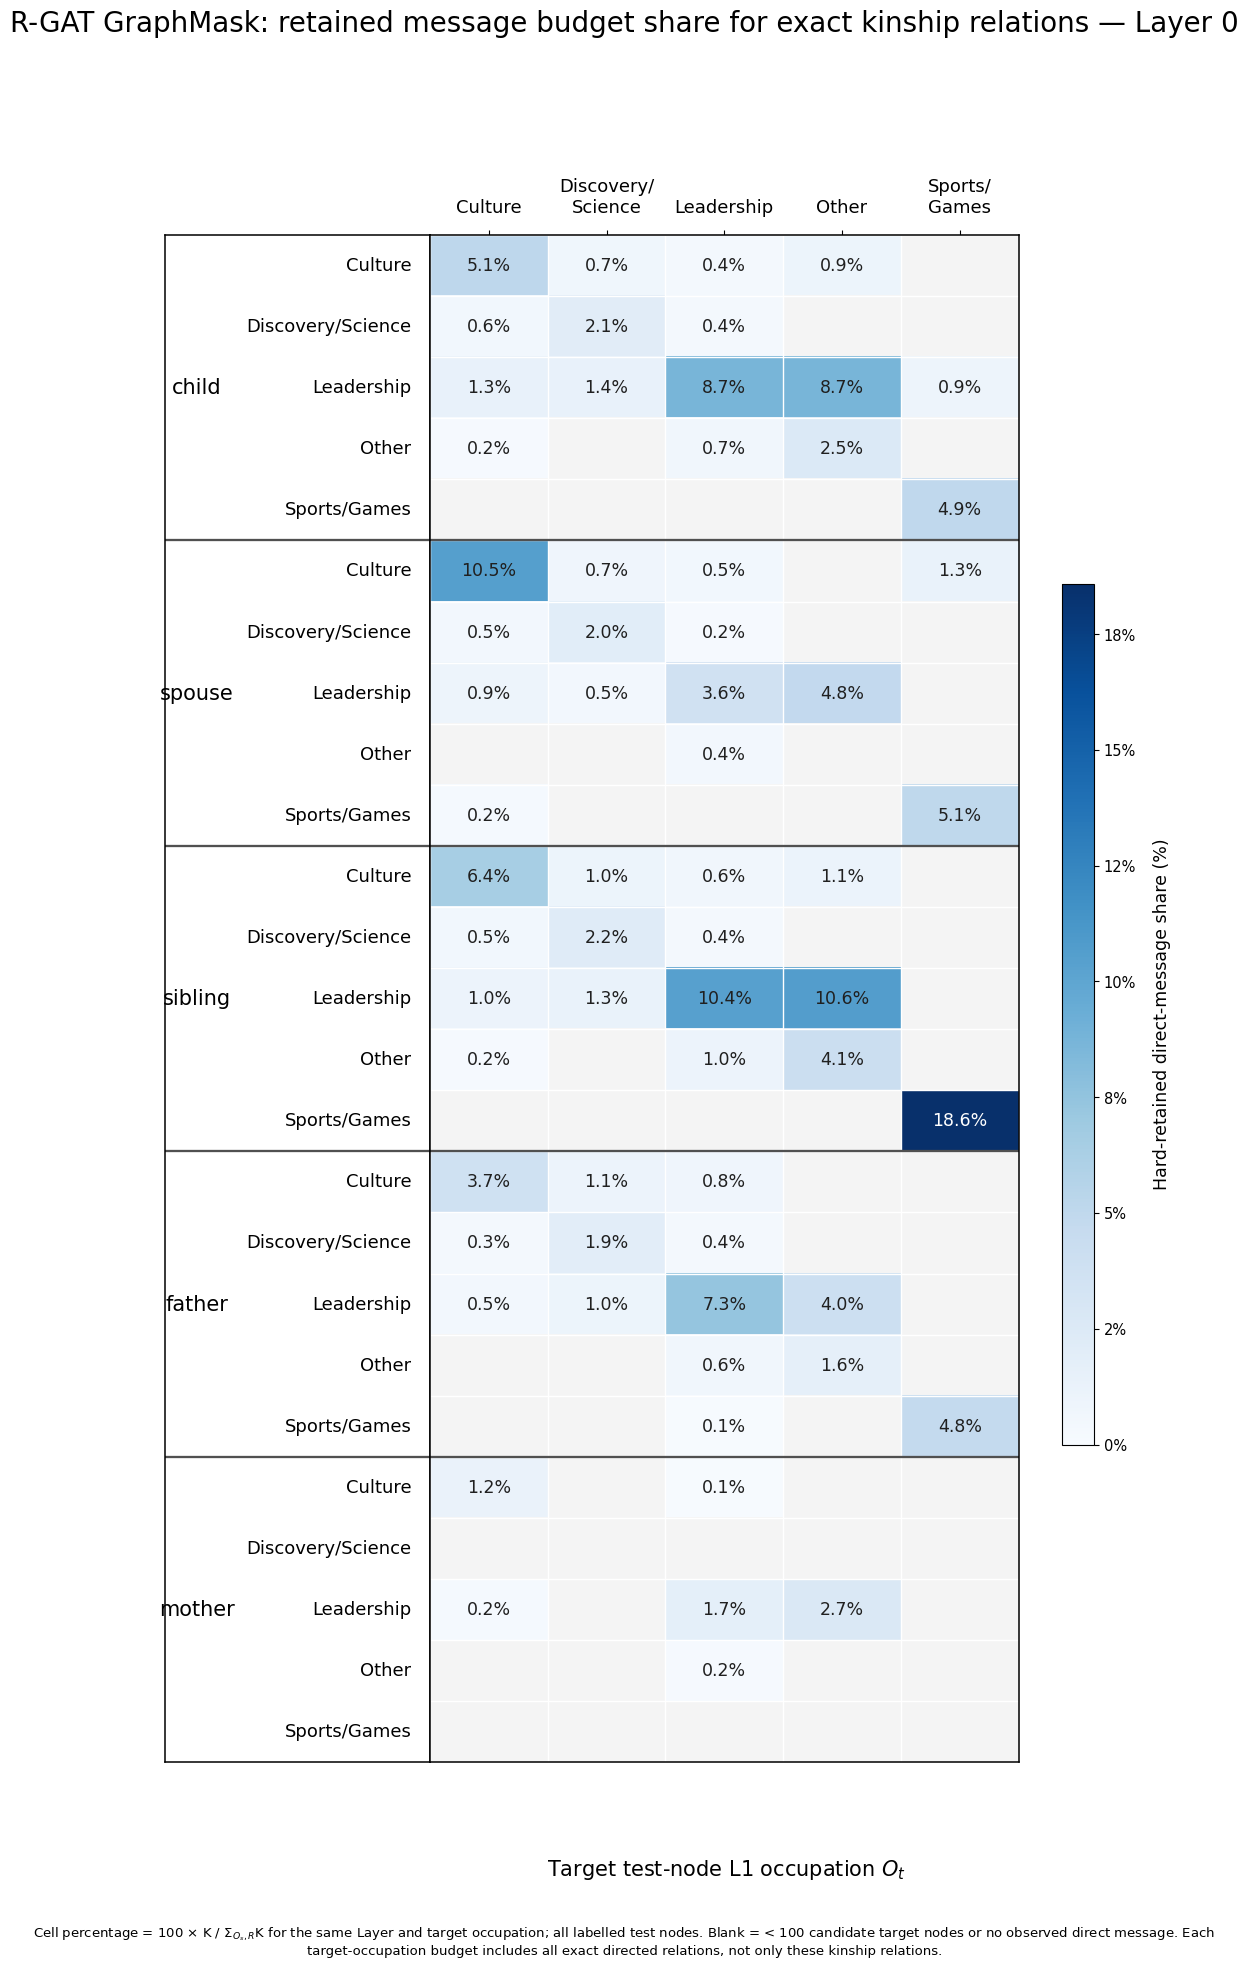

Saved exact-relation figure: /Users/wangyue/RGCN/visualization/graphmask_l1_rgat_all_test_layer0_retained_share_exact_kinship.png


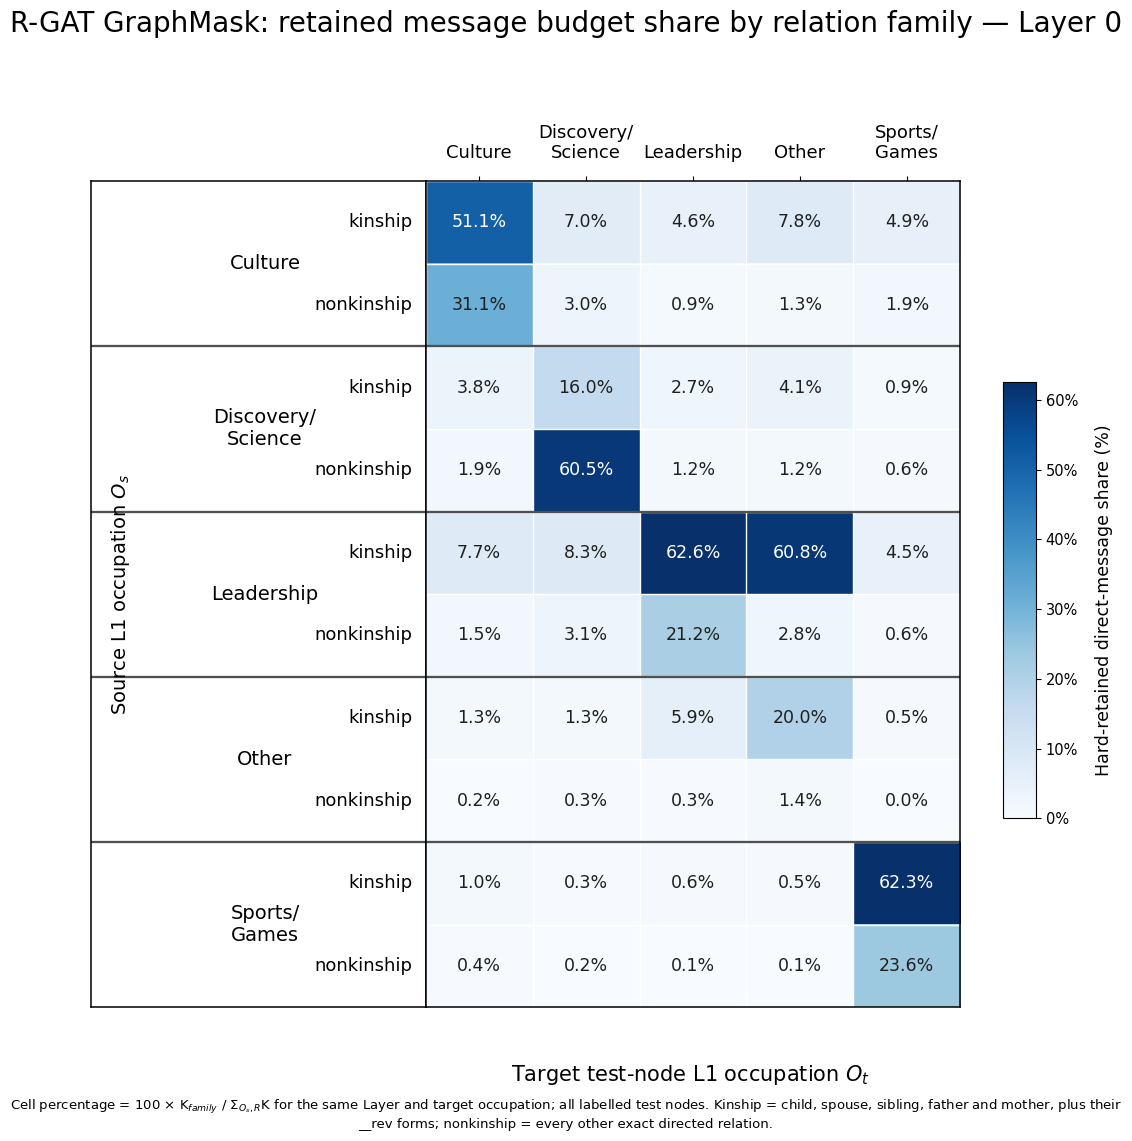

Saved relation-family figure: /Users/wangyue/RGCN/visualization/graphmask_l1_rgat_all_test_layer0_retained_share_relation_family.png


In [6]:
output_path = VISUALIZATION_DIR / OUTPUT_FILENAME
plot_retained_share_stacked(relations_to_plot, output_path)
print(f'Saved exact-relation figure: {output_path}')

family_output_path = VISUALIZATION_DIR / FAMILY_OUTPUT_FILENAME
plot_relation_family_share(family_output_path)
print(f'Saved relation-family figure: {family_output_path}')


## 诊断图：hard retention rate $K/N$

下面两张图沿用主图的职业—关系布局，但颜色和格内百分比改为 **hard retention rate**：该格子的候选直接消息中，被 GraphMask hard gate 保留的比例 $K/N$。

这是故意不加 candidate-node support 门槛的诊断视图，因此罕见组合也会显示；应将异常高值与末尾审计表中的 `candidate_message_n`、`candidate_node_count` 一起阅读，不能据此直接作正式排名或全局重要性结论。

In [7]:
# These diagnostic figures intentionally use every observed cell, without the main figure's support filter.
RETENTION_EXACT_OUTPUT_FILENAME = (
    f'graphmask_l1_rgat_{COHORT}_layer{LAYER}_hard_retention_rate_exact_kinship{output_tag_suffix}.png'
)
RETENTION_FAMILY_OUTPUT_FILENAME = (
    f'graphmask_l1_rgat_{COHORT}_layer{LAYER}_hard_retention_rate_relation_family{output_tag_suffix}.png'
)


def _retention_matrix(panel: pd.DataFrame, *, label: str) -> pd.DataFrame:
    """Build a source-by-target hard-retention-rate matrix from an unfiltered report panel."""
    key_columns = ['source_l1_id', 'target_l1_id']
    if panel.duplicated(key_columns).any():
        raise ValueError(f'Duplicate (source, target) retention cells for {label}.')
    values = _empty_share_matrix()
    source_lookup = {class_id: name for class_id, name in source_order.items()}
    target_lookup = {class_id: name for class_id, name in target_order.items()}
    for row in panel.itertuples(index=False):
        values.loc[source_lookup[row.source_l1_id], target_lookup[row.target_l1_id]] = (
            row.hard_retention_rate
        )
    return values


def exact_relation_retention_matrix(relation: str) -> pd.DataFrame:
    panel = layer_df.loc[layer_df['directed_relation'].eq(relation)].copy()
    return _retention_matrix(panel, label=f'relation {relation!r}')


def family_retention_matrices() -> dict[str, pd.DataFrame]:
    """Aggregate K and N first, then calculate K/N for each relation family."""
    family_df = layer_df.copy()
    family_df['relation_family'] = family_df['directed_relation'].map(relation_family)
    family_df = (
        family_df.groupby(
            ['source_l1_id', 'source_l1', 'target_l1_id', 'target_l1', 'relation_family'],
            as_index=False,
        )
        .agg(
            candidate_message_n=('candidate_message_n', 'sum'),
            hard_retained_message_n=('hard_retained_message_n', 'sum'),
        )
    )
    family_df['hard_retention_rate'] = (
        family_df['hard_retained_message_n'] / family_df['candidate_message_n']
    )
    return {
        family: _retention_matrix(
            family_df.loc[family_df['relation_family'].eq(family)].copy(),
            label=f'relation family {family!r}',
        )
        for family in RELATION_FAMILIES
    }


def _retention_colourbar(figure, image, axis) -> None:
    colourbar = figure.colorbar(image, cax=axis)
    colourbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    colourbar.set_label('Hard retention rate K/N (%)', fontsize=12.5, labelpad=12)
    colourbar.ax.tick_params(labelsize=10.5)


def plot_exact_retention_rate(relations: list[str], output_path: Path) -> None:
    """Plot exact-relation K/N with the existing tall kinship layout."""
    matrices = [(relation, exact_relation_retention_matrix(relation)) for relation in relations]
    values = np.vstack([matrix.to_numpy() for _, matrix in matrices])
    if not np.isfinite(values).any():
        raise ValueError('No observed exact-relation messages remain for this layer.')

    n_source, n_target = len(source_names), len(target_names)
    n_rows = len(relations) * n_source
    cmap = plt.colormaps['Blues'].copy()
    cmap.set_bad('#f4f4f4')
    figure = plt.figure(figsize=(10.8, 20.5))
    label_axis = figure.add_axes([0.075, 0.115, 0.245, 0.745])
    heat_axis = figure.add_axes([0.320, 0.115, 0.545, 0.745])
    colourbar_axis = figure.add_axes([0.905, 0.270, 0.030, 0.420])

    image = heat_axis.imshow(values, cmap=cmap, vmin=0.0, vmax=1.0, aspect='auto', interpolation='none')
    heat_axis.set_xlim(-0.5, n_target - 0.5)
    heat_axis.set_ylim(n_rows - 0.5, -0.5)
    heat_axis.set_yticks([])
    heat_axis.set_xticks(range(n_target))
    heat_axis.set_xticklabels([name.replace('/', '/\n') for name in target_names], fontsize=13)
    heat_axis.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False, pad=10)
    heat_axis.set_xticks(np.arange(-0.5, n_target, 1), minor=True)
    heat_axis.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    heat_axis.grid(which='minor', color='white', linewidth=1.0)
    heat_axis.tick_params(which='minor', bottom=False, left=False)
    for spine in heat_axis.spines.values():
        spine.set_linewidth(1.1)

    label_axis.set_xlim(0.0, 1.0)
    label_axis.set_ylim(n_rows - 0.5, -0.5)
    label_axis.set_xticks([])
    label_axis.set_yticks([])
    for spine in label_axis.spines.values():
        spine.set_linewidth(1.1)

    for relation_index, (relation, matrix) in enumerate(matrices):
        start = relation_index * n_source
        label_axis.text(0.12, start + (n_source - 1) / 2, relation, ha='center', va='center', fontsize=15)
        for source_index, source_name in enumerate(source_names):
            row = start + source_index
            label_axis.text(0.93, row, source_name, ha='right', va='center', fontsize=13)
            for target_index, value in enumerate(matrix.iloc[source_index]):
                if np.isfinite(value):
                    heat_axis.text(
                        target_index, row, f'{value:.1%}', ha='center', va='center',
                        color='white' if value >= 0.58 else '#202020', fontsize=12.5,
                    )

    for boundary in range(n_source, n_rows, n_source):
        heat_axis.axhline(boundary - 0.5, color='#505050', linewidth=1.65)
        label_axis.axhline(boundary - 0.5, color='#505050', linewidth=1.65)

    _retention_colourbar(figure, image, colourbar_axis)
    figure.suptitle(
        f'R-GAT GraphMask: hard retention rate for exact kinship relations — Layer {LAYER}',
        fontsize=20, y=0.970,
    )
    figure.text(0.595, 0.060, 'Target test-node L1 occupation $O_t$', ha='center', fontsize=15)
    figure.text(
        0.5, 0.020,
        'Cell percentage = hard-retained direct messages K / candidate direct messages N. All observed cells are shown: no candidate-node support filter. Interpret small-N cells with the audit table.',
        ha='center', va='bottom', fontsize=9.5, wrap=True,
    )
    figure.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(figure)


def plot_family_retention_rate(output_path: Path) -> None:
    """Plot family-level K/N after pooling all exact directed relations within each family."""
    matrices = family_retention_matrices()
    values = np.vstack([
        matrices[family].loc[source].to_numpy()
        for source in source_names
        for family in RELATION_FAMILIES
    ])
    if not np.isfinite(values).any():
        raise ValueError('No observed relation-family messages remain for this layer.')

    n_source, n_target = len(source_names), len(target_names)
    n_rows = n_source * len(RELATION_FAMILIES)
    cmap = plt.colormaps['Blues'].copy()
    cmap.set_bad('#f4f4f4')
    figure = plt.figure(figsize=(10.8, 11.8))
    label_axis = figure.add_axes([0.060, 0.125, 0.310, 0.700])
    heat_axis = figure.add_axes([0.370, 0.125, 0.495, 0.700])
    colourbar_axis = figure.add_axes([0.905, 0.285, 0.030, 0.370])

    image = heat_axis.imshow(values, cmap=cmap, vmin=0.0, vmax=1.0, aspect='auto', interpolation='none')
    heat_axis.set_xlim(-0.5, n_target - 0.5)
    heat_axis.set_ylim(n_rows - 0.5, -0.5)
    heat_axis.set_yticks([])
    heat_axis.set_xticks(range(n_target))
    heat_axis.set_xticklabels([name.replace('/', '/\n') for name in target_names], fontsize=13)
    heat_axis.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False, pad=10)
    heat_axis.set_xticks(np.arange(-0.5, n_target, 1), minor=True)
    heat_axis.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    heat_axis.grid(which='minor', color='white', linewidth=1.0)
    heat_axis.tick_params(which='minor', bottom=False, left=False)
    for spine in heat_axis.spines.values():
        spine.set_linewidth(1.1)

    label_axis.set_xlim(0.0, 1.0)
    label_axis.set_ylim(n_rows - 0.5, -0.5)
    label_axis.set_xticks([])
    label_axis.set_yticks([])
    for spine in label_axis.spines.values():
        spine.set_linewidth(1.1)

    for source_index, source_name in enumerate(source_names):
        start = source_index * len(RELATION_FAMILIES)
        label_axis.text(0.52, start + 0.5, source_name.replace('/', '/\n'), ha='center', va='center', fontsize=14)
        for family_index, family in enumerate(RELATION_FAMILIES):
            row = start + family_index
            label_axis.text(0.96, row, family, ha='right', va='center', fontsize=13)
            for target_index, value in enumerate(values[row]):
                if np.isfinite(value):
                    heat_axis.text(
                        target_index, row, f'{value:.1%}', ha='center', va='center',
                        color='white' if value >= 0.58 else '#202020', fontsize=12.5,
                    )

    for boundary in range(len(RELATION_FAMILIES), n_rows, len(RELATION_FAMILIES)):
        heat_axis.axhline(boundary - 0.5, color='#505050', linewidth=1.65)
        label_axis.axhline(boundary - 0.5, color='#505050', linewidth=1.65)

    label_axis.text(0.09, (n_rows - 1) / 2, 'Source L1 occupation $O_s$', rotation=90, ha='center', va='center', fontsize=14)
    _retention_colourbar(figure, image, colourbar_axis)
    figure.suptitle(
        f'R-GAT GraphMask: hard retention rate by relation family — Layer {LAYER}',
        fontsize=20, y=0.970,
    )
    figure.text(0.615, 0.062, 'Target test-node L1 occupation $O_t$', ha='center', fontsize=15)
    figure.text(
        0.5, 0.020,
        'Cell percentage = pooled family hard-retained direct messages K / pooled family candidate direct messages N. All observed cells are shown: no candidate-node support filter.',
        ha='center', va='bottom', fontsize=9.5, wrap=True,
    )
    figure.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(figure)


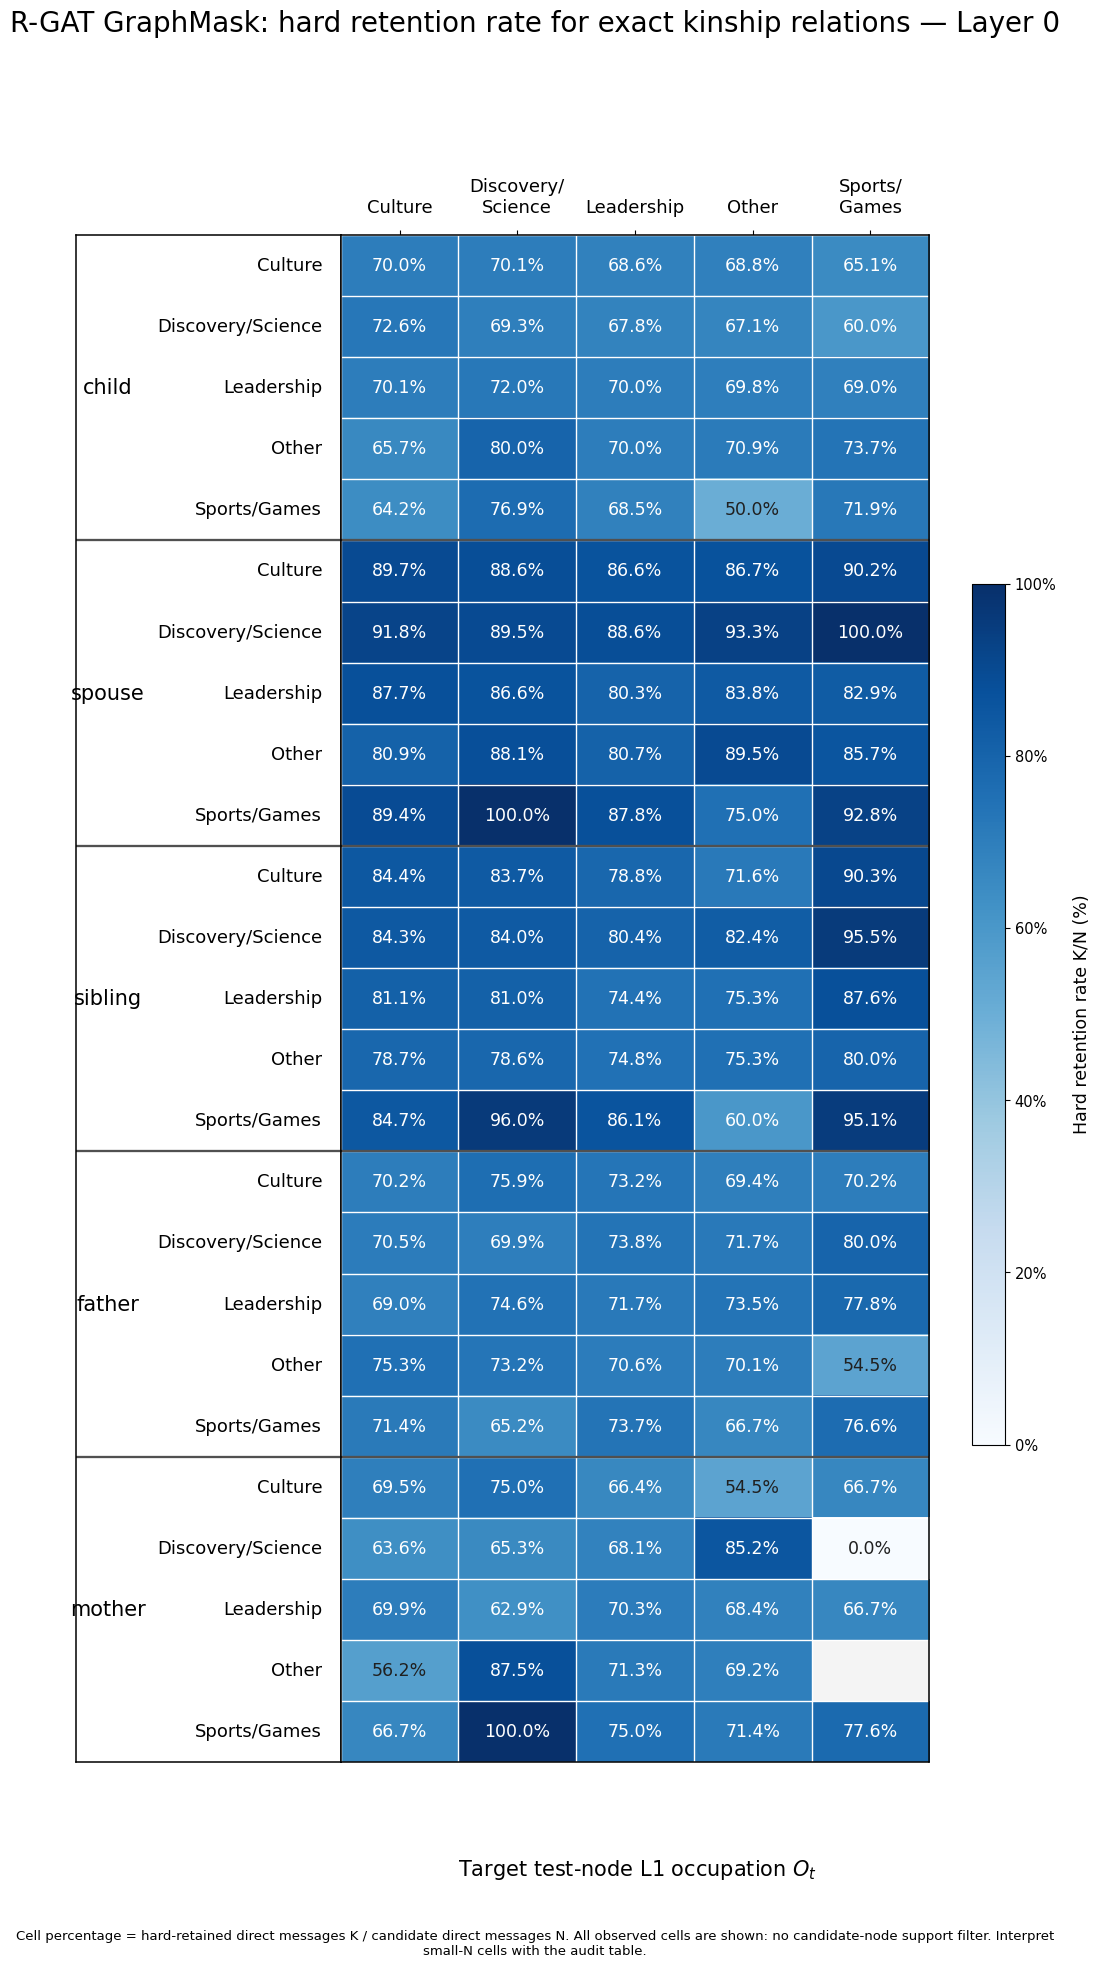

Saved exact-relation retention-rate figure: /Users/wangyue/RGCN/visualization/graphmask_l1_rgat_all_test_layer0_hard_retention_rate_exact_kinship.png


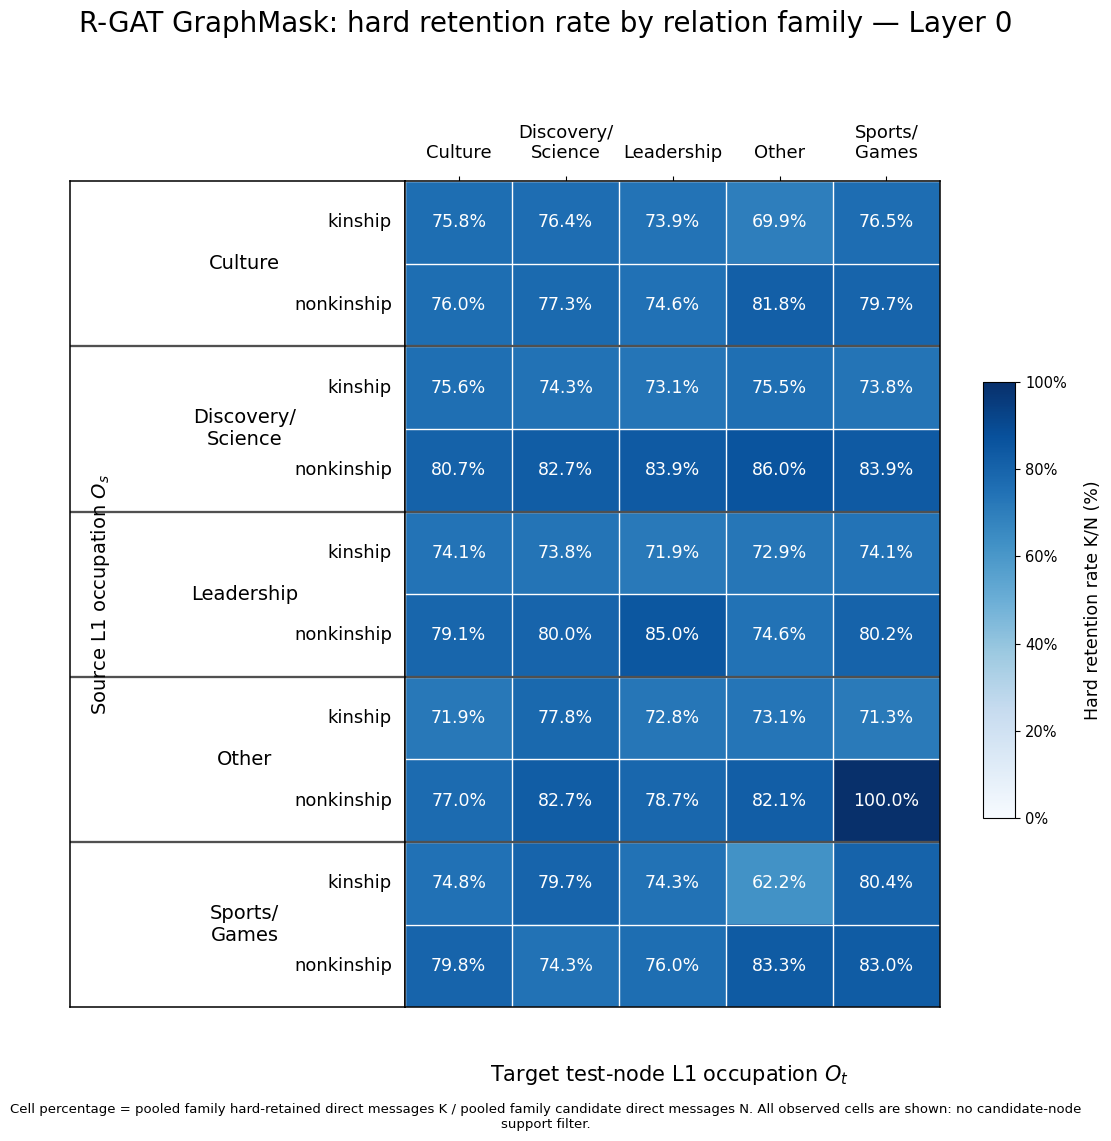

Saved relation-family retention-rate figure: /Users/wangyue/RGCN/visualization/graphmask_l1_rgat_all_test_layer0_hard_retention_rate_relation_family.png


In [8]:
retention_exact_output_path = VISUALIZATION_DIR / RETENTION_EXACT_OUTPUT_FILENAME
plot_exact_retention_rate(relations_to_plot, retention_exact_output_path)
print(f'Saved exact-relation retention-rate figure: {retention_exact_output_path}')

retention_family_output_path = VISUALIZATION_DIR / RETENTION_FAMILY_OUTPUT_FILENAME
plot_family_retention_rate(retention_family_output_path)
print(f'Saved relation-family retention-rate figure: {retention_family_output_path}')


## 全局 retained-message share：全图的分母固定

这一组图的分母不再固定为某一目标职业的预算，而是当前 Layer、当前 cohort（及当前 visibility slice，如有）中 **全部已知来源、全部目标职业、全部精确有向关系的 hard-retained 直接消息总数**。

因此 relation-family 图覆盖全部关系和全部职业组合，其所有格子相加严格为 100%。exact-kinship 图只展示五种正向亲属关系，因此它展示的是这 100% 全局预算中的一个子集，而不会被要求相加为 100%。

In [9]:
GLOBAL_SHARE_EXACT_OUTPUT_FILENAME = (
    f'graphmask_l1_rgat_{COHORT}_layer{LAYER}_global_retained_share_exact_kinship{output_tag_suffix}.png'
)
GLOBAL_SHARE_FAMILY_OUTPUT_FILENAME = (
    f'graphmask_l1_rgat_{COHORT}_layer{LAYER}_global_retained_share_relation_family{output_tag_suffix}.png'
)

# This denominator is intentionally fixed for every cell in these two figures.
GLOBAL_HARD_RETAINED_TOTAL = int(layer_df['hard_retained_message_n'].sum())
if GLOBAL_HARD_RETAINED_TOTAL <= 0:
    raise ValueError('The selected layer has no known-source direct hard-retained messages.')


def _global_share_matrix(panel: pd.DataFrame, *, label: str) -> pd.DataFrame:
    """Return K_cell / K_all for one exact relation or relation family."""
    key_columns = ['source_l1_id', 'target_l1_id']
    if panel.duplicated(key_columns).any():
        raise ValueError(f'Duplicate (source, target) global-share cells for {label}.')
    values = _empty_share_matrix()
    source_lookup = {class_id: name for class_id, name in source_order.items()}
    target_lookup = {class_id: name for class_id, name in target_order.items()}
    for row in panel.itertuples(index=False):
        values.loc[source_lookup[row.source_l1_id], target_lookup[row.target_l1_id]] = (
            row.hard_retained_message_n / GLOBAL_HARD_RETAINED_TOTAL
        )
    return values


def exact_relation_global_share_matrix(relation: str) -> pd.DataFrame:
    panel = layer_df.loc[layer_df['directed_relation'].eq(relation)].copy()
    return _global_share_matrix(panel, label=f'relation {relation!r}')


def family_global_share_matrices() -> dict[str, pd.DataFrame]:
    """Pool hard-retained K within a family, then divide by the one global K total."""
    family_df = layer_df.copy()
    family_df['relation_family'] = family_df['directed_relation'].map(relation_family)
    family_df = (
        family_df.groupby(
            ['source_l1_id', 'source_l1', 'target_l1_id', 'target_l1', 'relation_family'],
            as_index=False,
        )
        .agg(hard_retained_message_n=('hard_retained_message_n', 'sum'))
    )
    matrices = {
        family: _global_share_matrix(
            family_df.loc[family_df['relation_family'].eq(family)].copy(),
            label=f'relation family {family!r}',
        )
        for family in RELATION_FAMILIES
    }
    family_global_share_sum = sum(
        float(np.nansum(matrix.to_numpy())) for matrix in matrices.values()
    )
    assert abs(family_global_share_sum - 1.0) < 1e-8, (
        'The kinship/nonkinship global-share figure does not reconstruct 100% of the retained-message budget.'
    )
    return matrices


GLOBAL_FAMILY_SHARE_MATRICES = family_global_share_matrices()
GLOBAL_SHARE_VMAX = max(
    float(np.nanmax(matrix.to_numpy())) for matrix in GLOBAL_FAMILY_SHARE_MATRICES.values()
)


def _global_share_colourbar(figure, image, axis) -> None:
    colourbar = figure.colorbar(image, cax=axis)
    colourbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    colourbar.set_label('Global hard-retained message share (%)', fontsize=12.5, labelpad=12)
    colourbar.ax.tick_params(labelsize=10.5)


def plot_exact_global_share(relations: list[str], output_path: Path) -> None:
    """Plot K_cell / K_all for the five forward kinship relations."""
    matrices = [(relation, exact_relation_global_share_matrix(relation)) for relation in relations]
    values = np.vstack([matrix.to_numpy() for _, matrix in matrices])
    if not np.isfinite(values).any():
        raise ValueError('No observed exact-relation messages remain for this layer.')

    n_source, n_target = len(source_names), len(target_names)
    n_rows = len(relations) * n_source
    cmap = plt.colormaps['Blues'].copy()
    cmap.set_bad('#f4f4f4')
    # Exact forward-kinship cells occupy only a small subset of the full retained-message budget.
    # Scale this diagnostic to its own maximum; the relation-family figure intentionally keeps
    # the full-budget range because all of its cells jointly sum to 100%.
    exact_share_vmax = float(np.nanmax(values))
    figure = plt.figure(figsize=(10.8, 20.5))
    label_axis = figure.add_axes([0.075, 0.115, 0.245, 0.745])
    heat_axis = figure.add_axes([0.320, 0.115, 0.545, 0.745])
    colourbar_axis = figure.add_axes([0.905, 0.270, 0.030, 0.420])

    image = heat_axis.imshow(values, cmap=cmap, vmin=0.0, vmax=exact_share_vmax, aspect='auto', interpolation='none')
    heat_axis.set_xlim(-0.5, n_target - 0.5)
    heat_axis.set_ylim(n_rows - 0.5, -0.5)
    heat_axis.set_yticks([])
    heat_axis.set_xticks(range(n_target))
    heat_axis.set_xticklabels([name.replace('/', '/\n') for name in target_names], fontsize=13)
    heat_axis.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False, pad=10)
    heat_axis.set_xticks(np.arange(-0.5, n_target, 1), minor=True)
    heat_axis.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    heat_axis.grid(which='minor', color='white', linewidth=1.0)
    heat_axis.tick_params(which='minor', bottom=False, left=False)
    for spine in heat_axis.spines.values():
        spine.set_linewidth(1.1)

    label_axis.set_xlim(0.0, 1.0)
    label_axis.set_ylim(n_rows - 0.5, -0.5)
    label_axis.set_xticks([])
    label_axis.set_yticks([])
    for spine in label_axis.spines.values():
        spine.set_linewidth(1.1)

    for relation_index, (relation, matrix) in enumerate(matrices):
        start = relation_index * n_source
        label_axis.text(0.12, start + (n_source - 1) / 2, relation, ha='center', va='center', fontsize=15)
        for source_index, source_name in enumerate(source_names):
            row = start + source_index
            label_axis.text(0.93, row, source_name, ha='right', va='center', fontsize=13)
            for target_index, value in enumerate(matrix.iloc[source_index]):
                if np.isfinite(value):
                    heat_axis.text(
                        target_index, row, f'{value:.1%}', ha='center', va='center',
                        color='white' if value / exact_share_vmax >= 0.58 else '#202020', fontsize=12.5,
                    )

    for boundary in range(n_source, n_rows, n_source):
        heat_axis.axhline(boundary - 0.5, color='#505050', linewidth=1.65)
        label_axis.axhline(boundary - 0.5, color='#505050', linewidth=1.65)

    _global_share_colourbar(figure, image, colourbar_axis)
    figure.suptitle(
        f'R-GAT GraphMask: global retained-message share for exact kinship relations — Layer {LAYER}',
        fontsize=20, y=0.970,
    )
    figure.text(0.595, 0.060, 'Target test-node L1 occupation $O_t$', ha='center', fontsize=15)
    figure.text(
        0.5, 0.020,
        'Cell percentage = K_cell / K_all for this Layer. K_all includes every observed known-source direct message across all source occupations, target occupations and exact directed relations. Only five forward kinship relations are displayed here, so this grid is a subset of the 100% budget. The colour scale ends at the largest displayed exact-kinship cell.',
        ha='center', va='bottom', fontsize=9.5, wrap=True,
    )
    figure.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(figure)


def plot_family_global_share(output_path: Path) -> None:
    """Plot K_family_cell / K_all; all 50 cells reconstruct the full 100% budget."""
    values = np.vstack([
        GLOBAL_FAMILY_SHARE_MATRICES[family].loc[source].to_numpy()
        for source in source_names
        for family in RELATION_FAMILIES
    ])
    n_source, n_target = len(source_names), len(target_names)
    n_rows = n_source * len(RELATION_FAMILIES)
    cmap = plt.colormaps['Blues'].copy()
    cmap.set_bad('#f4f4f4')
    figure = plt.figure(figsize=(10.8, 11.8))
    label_axis = figure.add_axes([0.060, 0.125, 0.310, 0.700])
    heat_axis = figure.add_axes([0.370, 0.125, 0.495, 0.700])
    colourbar_axis = figure.add_axes([0.905, 0.285, 0.030, 0.370])

    image = heat_axis.imshow(values, cmap=cmap, vmin=0.0, vmax=GLOBAL_SHARE_VMAX, aspect='auto', interpolation='none')
    heat_axis.set_xlim(-0.5, n_target - 0.5)
    heat_axis.set_ylim(n_rows - 0.5, -0.5)
    heat_axis.set_yticks([])
    heat_axis.set_xticks(range(n_target))
    heat_axis.set_xticklabels([name.replace('/', '/\n') for name in target_names], fontsize=13)
    heat_axis.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False, pad=10)
    heat_axis.set_xticks(np.arange(-0.5, n_target, 1), minor=True)
    heat_axis.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    heat_axis.grid(which='minor', color='white', linewidth=1.0)
    heat_axis.tick_params(which='minor', bottom=False, left=False)
    for spine in heat_axis.spines.values():
        spine.set_linewidth(1.1)

    label_axis.set_xlim(0.0, 1.0)
    label_axis.set_ylim(n_rows - 0.5, -0.5)
    label_axis.set_xticks([])
    label_axis.set_yticks([])
    for spine in label_axis.spines.values():
        spine.set_linewidth(1.1)

    for source_index, source_name in enumerate(source_names):
        start = source_index * len(RELATION_FAMILIES)
        label_axis.text(0.52, start + 0.5, source_name.replace('/', '/\n'), ha='center', va='center', fontsize=14)
        for family_index, family in enumerate(RELATION_FAMILIES):
            row = start + family_index
            label_axis.text(0.96, row, family, ha='right', va='center', fontsize=13)
            for target_index, value in enumerate(values[row]):
                if np.isfinite(value):
                    heat_axis.text(
                        target_index, row, f'{value:.1%}', ha='center', va='center',
                        color='white' if value / GLOBAL_SHARE_VMAX >= 0.58 else '#202020', fontsize=12.5,
                    )

    for boundary in range(len(RELATION_FAMILIES), n_rows, len(RELATION_FAMILIES)):
        heat_axis.axhline(boundary - 0.5, color='#505050', linewidth=1.65)
        label_axis.axhline(boundary - 0.5, color='#505050', linewidth=1.65)

    label_axis.text(0.09, (n_rows - 1) / 2, 'Source L1 occupation $O_s$', rotation=90, ha='center', va='center', fontsize=14)
    _global_share_colourbar(figure, image, colourbar_axis)
    figure.suptitle(
        f'R-GAT GraphMask: global retained-message share by relation family — Layer {LAYER}',
        fontsize=20, y=0.970,
    )
    figure.text(0.615, 0.062, 'Target test-node L1 occupation $O_t$', ha='center', fontsize=15)
    figure.text(
        0.5, 0.020,
        'Cell percentage = K_family_cell / K_all for this Layer. Kinship and nonkinship jointly cover every exact directed relation, so all cells in this entire grid sum to 100%.',
        ha='center', va='bottom', fontsize=9.5, wrap=True,
    )
    figure.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(figure)


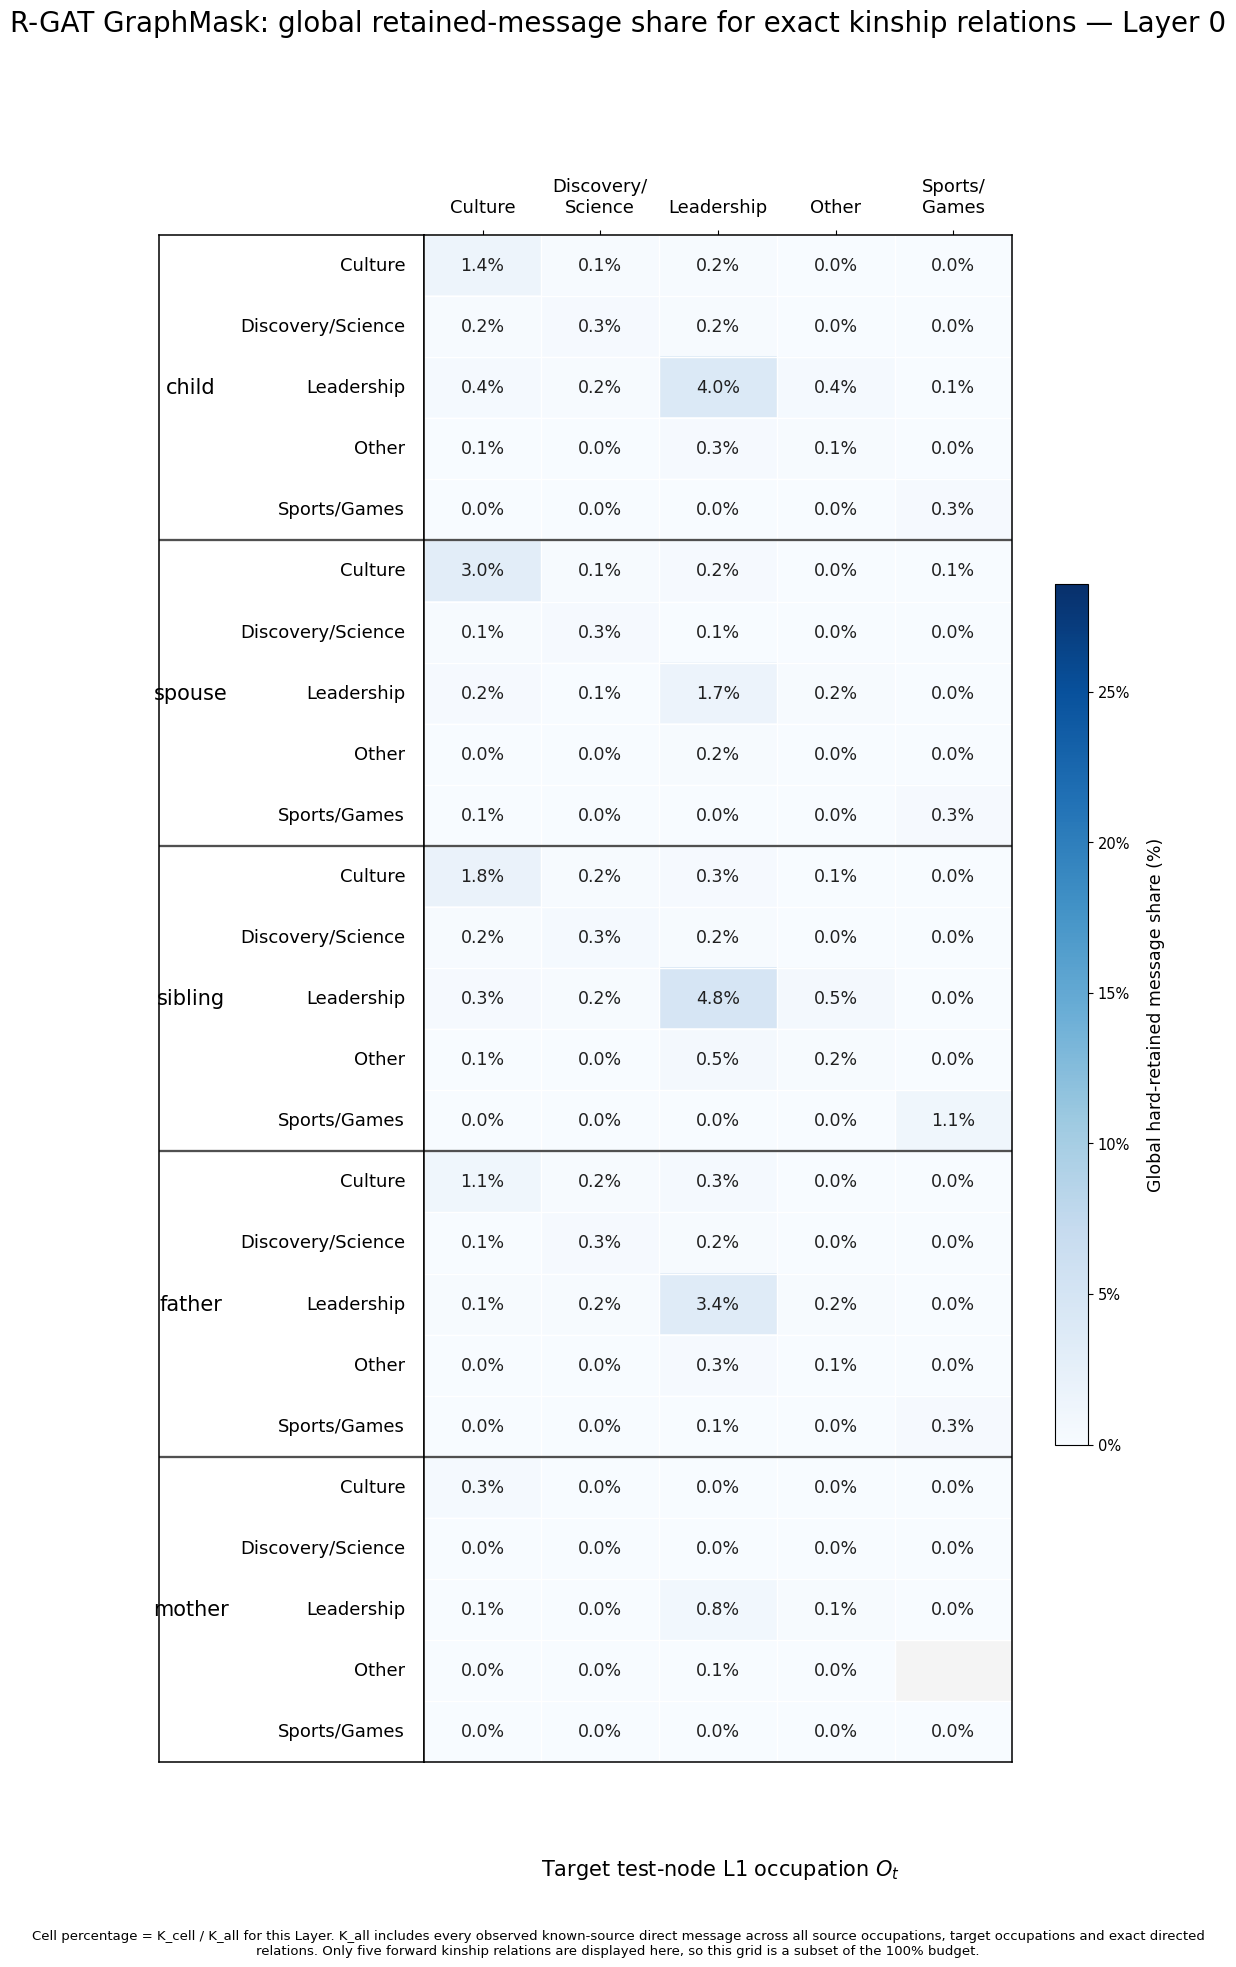

Saved exact-relation global-share figure: /Users/wangyue/RGCN/visualization/graphmask_l1_rgat_all_test_layer0_global_retained_share_exact_kinship.png


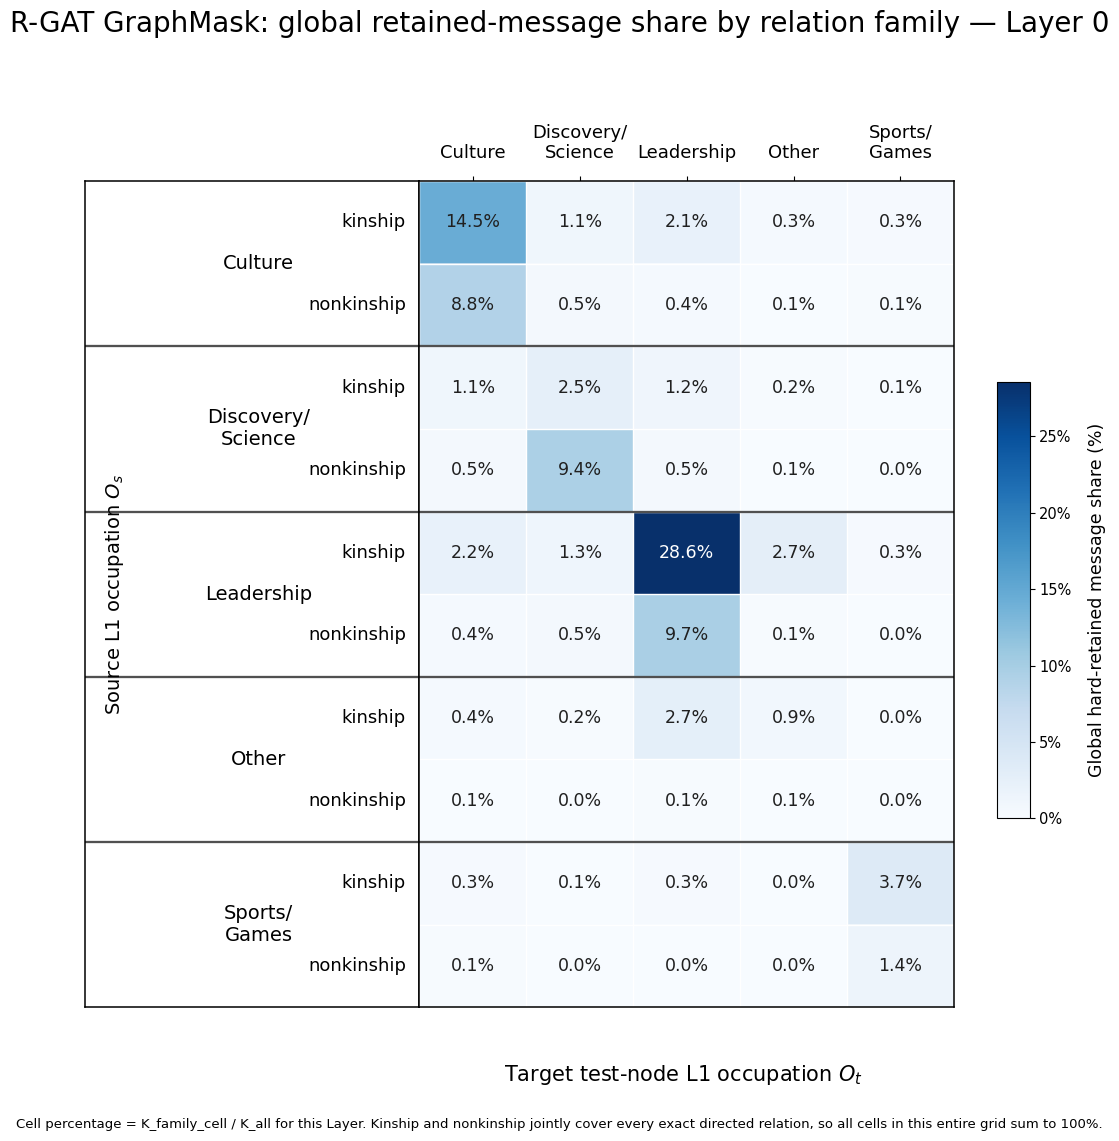

Saved relation-family global-share figure: /Users/wangyue/RGCN/visualization/graphmask_l1_rgat_all_test_layer0_global_retained_share_relation_family.png


In [10]:
global_share_exact_output_path = VISUALIZATION_DIR / GLOBAL_SHARE_EXACT_OUTPUT_FILENAME
plot_exact_global_share(relations_to_plot, global_share_exact_output_path)
print(f'Saved exact-relation global-share figure: {global_share_exact_output_path}')

global_share_family_output_path = VISUALIZATION_DIR / GLOBAL_SHARE_FAMILY_OUTPUT_FILENAME
plot_family_global_share(global_share_family_output_path)
print(f'Saved relation-family global-share figure: {global_share_family_output_path}')


## 扩展：同一布局下的留存率或 lift

若主图显示某一组合占据很大“重要消息预算”，下一步可检查这是不是因为该组合本来就很常见。下面的汇总表保留了用于判读的三个互补量：

- `hard_retention_rate = K/N`：该组合供给的消息中，有多少被 GraphMask 保留；
- `retention_lift_within_R_Ot`：固定关系 $R$ 和目标职业 $O_t$ 后，来源职业 $O_s$ 的保留程度相对于它的候选消息供给是否被过度代表；大于 1 代表高于该条件平均；
- `candidate_node_coverage` 与 `retained_node_coverage`：多少测试节点受到该组合覆盖。

不要把这三者与主图份额混成单一分数；它们分别对应消息预算、选择倾向和节点覆盖。

In [11]:
# Compact audit table for the exact cells that are visible in the main figure.
audit_columns = [
    'directed_relation', 'source_l1', 'target_l1',
    'hard_retained_message_n', 'candidate_message_n', 'hard_retention_rate',
    'retained_share_of_Ot_budget', 'candidate_node_coverage', 'retained_node_coverage',
    'retention_lift_within_R_Ot',
]
audit_table = (
    plot_df[audit_columns]
    .sort_values(['directed_relation', 'target_l1', 'retained_share_of_Ot_budget'], ascending=[True, True, False])
    .reset_index(drop=True)
)
display(audit_table)


,directed_relation,source_l1,target_l1,hard_retained_message_n,candidate_message_n,hard_retention_rate,retained_share_of_Ot_budget,candidate_node_coverage,retained_node_coverage,retention_lift_within_R_Ot
0,child,Culture,Culture,3029,4326,0.700185,0.051003,0.165047,0.122144,0.999779
1,child,Leadership,Culture,796,1135,0.701322,0.013403,0.047207,0.034030,1.001402
2,child,Discovery/Science,Culture,339,467,0.725910,0.005708,0.020232,0.014730,1.036512
3,child,Other,Culture,117,178,0.657303,0.001970,0.007498,0.004969,0.938550
4,child,Discovery/Science,Discovery/Science,677,977,0.692938,0.020722,0.085793,0.059770,0.979936
...,...,...,...,...,...,...,...,...,...,...
60,spouse,Other,Leadership,417,517,0.806576,0.004362,0.020047,0.016319,0.991885
61,spouse,Discovery/Science,Leadership,163,184,0.885870,0.001705,0.007217,0.006455,1.089396
62,spouse,Leadership,Other,445,531,0.838041,0.048030,0.211097,0.179887,0.983337
63,spouse,Sports/Games,Sports/Games,636,685,0.928467,0.050702,0.118364,0.110357,1.009541
